# Pipeline ML — Preprocesado, Entrenamiento y Matriz de Confusión

Este notebook muestra cómo ejecutar los scripts del proyecto desde celdas de Jupyter y cómo verificar resultados. Hay dos opciones:\
\1) Ejecutar los scripts tal como están usando `%run` (rápido, mantiene el código en archivos).\
\2) Copiar el contenido de los scripts dentro de celdas si prefieres editar/ejecutar línea a línea.

Asegúrate de seleccionar el kernel `Python (.venv)` antes de ejecutar las celdas para que se use el entorno virtual del proyecto.

In [1]:
# 1) Comprobar intérprete del kernel
import sys, os
print('sys.executable ->', sys.executable)
print('cwd ->', os.getcwd())
# Mostrar versión de pip y si pandas está importable
try:
    import pandas as pd
    print('pandas ->', pd.__version__, 'from', pd.__file__)
except Exception as e:
    print('pandas no importable:', e)


sys.executable -> c:\Users\Julio\AppData\Local\Programs\Python\Python312\python.exe
cwd -> d:\User\onedrive\Documentos\TP-1ASI0404-12621-grupo1\notebooks
pandas -> 2.3.3 from c:\Users\Julio\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\__init__.py
pandas -> 2.3.3 from c:\Users\Julio\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\__init__.py


In [2]:
# 1.b) Instalar y verificar scikit-learn en el intérprete del kernel activo
import sys, subprocess, os
print('sys.executable ->', sys.executable)
print('cwd ->', os.getcwd())

def run(cmd):
    print('>',' '.join(cmd))
    subprocess.check_call(cmd)

# 1) Actualizar pip/setuptools/wheel (seguro y rápido)
try:
    run([sys.executable, '-m', 'pip', 'install', '--upgrade', 'pip', 'setuptools', 'wheel'])
except subprocess.CalledProcessError as e:
    print('Error al actualizar pip/setuptools/wheel:', e)

# 2) Instalar scikit-learn
try:
    run([sys.executable, '-m', 'pip', 'install', 'scikit-learn'])
except subprocess.CalledProcessError as e:
    print('Error al instalar scikit-learn:', e)

# 3) Verificar importación y versión
try:
    import importlib
    sklearn = importlib.import_module('sklearn')
    print('sklearn ->', sklearn.__version__, 'from', sklearn.__file__)
except Exception as e:
    print('No se pudo importar sklearn después de la instalación:', e)

sys.executable -> c:\Users\Julio\AppData\Local\Programs\Python\Python312\python.exe
cwd -> d:\User\onedrive\Documentos\TP-1ASI0404-12621-grupo1\notebooks
> c:\Users\Julio\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip setuptools wheel
> c:\Users\Julio\AppData\Local\Programs\Python\Python312\python.exe -m pip install scikit-learn
> c:\Users\Julio\AppData\Local\Programs\Python\Python312\python.exe -m pip install scikit-learn
sklearn -> 1.7.2 from c:\Users\Julio\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\__init__.py
sklearn -> 1.7.2 from c:\Users\Julio\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\__init__.py


## 2) Ejecutar preprocesado (usa el script `scripts/preprocess.py`)

In [3]:
# Opción A: ejecutar el script tal cual con %run (mantiene el código en archivos)
%run -i ../scripts/preprocess.py

Saved: train=1200, val=150, test=150


## 3) Entrenamiento del clasificador Naive Bayes (script `scripts/train_nb.py`)

In [4]:
# Ejecutar entrenamiento (puede tardar unos segundos)
%run -i ../scripts/train_nb.py

Validation results:
              precision    recall  f1-score   support

      accion       1.00      1.00      1.00        22
      comida       1.00      1.00      1.00        33
       lugar       0.97      1.00      0.99        34
      objeto       1.00      0.97      0.98        31
      saludo       1.00      1.00      1.00        30

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150

Test results:
              precision    recall  f1-score   support

      accion       1.00      1.00      1.00        33
      comida       1.00      1.00      1.00        28
       lugar       0.91      1.00      0.95        30
      objeto       1.00      0.90      0.95        30
      saludo       1.00      1.00      1.00        29

    accuracy                           0.98       150
   macro avg       0.98      0.98      0.98       150
weighted avg       0.98      0.98      0.98

## 4) Generar y visualizar matriz de confusión normalizada

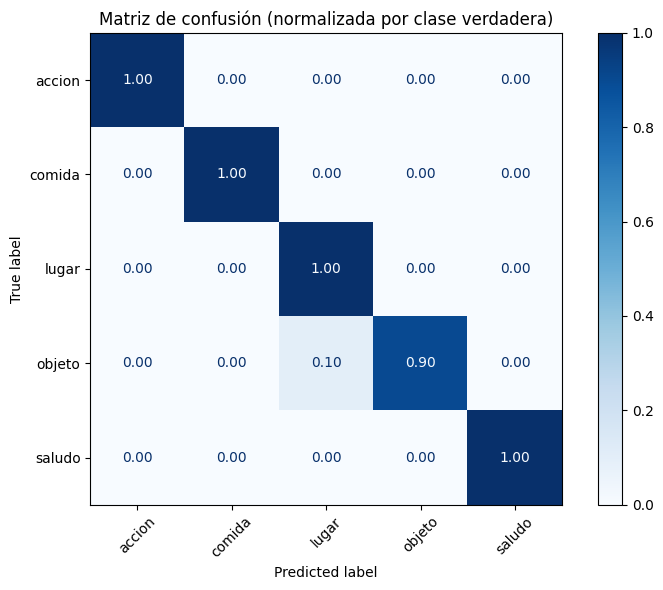

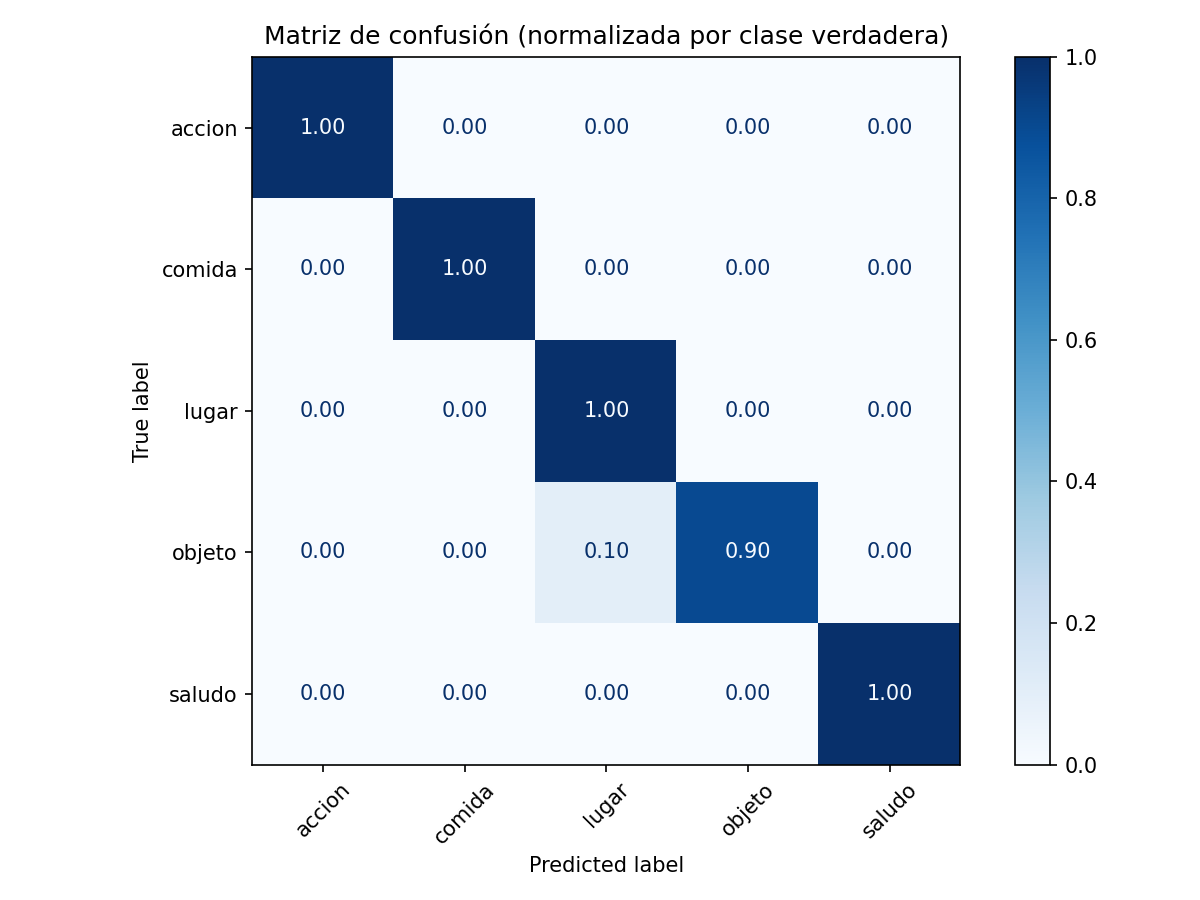

In [9]:
# Ejecutar el script que genera la imagen (si existe)
# si el script espera rutas relativas, %run lo ejecuta desde la carpeta 'notebooks', por eso usamos ../
%run -i ../scripts/"Matriz_de_confusión(normalizada).py"
# Mostrar la imagen guardada en outputs/confusion.png si existe
from IPython.display import Image, display
img_path = '../outputs/confusion.png'
if os.path.exists(img_path):
    display(Image(filename=img_path))
else:
    print('No se encontró', img_path)


## 5) Alternativa: insertar código directamente en celdas
Si prefieres editar línea a línea, puedes abrir los archivos `scripts/*.py` y copiar las secciones relevantes a celdas del notebook. Esto facilita depuración interactiva.

In [10]:
# Ejemplo: cargar modelo entrenado y ejecutar una predicción rápida
import pickle, json, os
model_path = os.path.join('..', 'models', 'nb_model.pkl')
vec_path = os.path.join('..', 'models', 'vectorizer.pkl')
if os.path.exists(model_path) and os.path.exists(vec_path):
    clf = pickle.load(open(model_path, 'rb'))
    vect = pickle.load(open(vec_path, 'rb'))
    sample = 'comer manzana'
    X = vect.transform([sample])
    pred = clf.predict(X)
    probs = clf.predict_proba(X) if hasattr(clf, 'predict_proba') else None
    print('input:', sample, '-> pred:', pred, 'probs:', probs)
else:
    print('Modelos no encontrados en ../models. Ejecuta primero el entrenamiento.')

input: comer manzana -> pred: ['accion'] probs: [[0.57290637 0.1137477  0.11331979 0.1137477  0.08627844]]
